In [ ]:
###############################################################################
# AI & OPTIMIZATION - LAB 02 - 2025/2026
###############################################################################

In [1]:
# System imports
import matplotlib.pyplot as plt
import numpy as np

#Extra library imports
import pandas as pd
from scipy.optimize import minimize

In [2]:
# User inputs
color_dict = {'benign': 'g', 'malignant': 'r'}
csvpath = 'data.csv'
nb_its = 500

Breast cancer is the most common cancer among women in France, and also the leading cause of cancer death in women. If the presence of a lesion is suspected after a breast cancer screening, the diagnosis can be confirmed performing a biopsy, i.e. the extraction of a sample of the abnormal tissue on the patient. The analysis of the collected sample using microscopic techniques allows detecting malignant breast cells, that differ from healthy cells in features such as shape, density or size. In this lab, we will more especially focus on the circularity of breast cells, to study if it is a potential tumor marker. 

# I. Linear regression on breast cells' features using gradient descent

## a) Exploration of  the dataset

We will now study samples extracted from the breast cancer wisconsin dataset, collecting features on healthy and malignant cells. You may find additional information about this dataset on https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic).

<font color='blue'> Question 1: load the dataset in the 'reast_csv' file using the *read_csv* function of pandas. Compute automatically and display the number of samples and potential features in this dataset using the *shape* attribute of pandas.</font>

In [4]:
# Load the dataset
df = pd.read_csv(csvpath)
nb_samples = df.shape[0]
nb_feats = df.shape[1] 
print('{0} samples and {1} potential features'.format(nb_samples, nb_feats))

150 samples and 4 potential features


<font color='blue'> Question 2: display all the potential feature names, *i.e.* the names of the columns of the loaded dataframe. </font>

In [7]:
# Display all the potential feature names
featnames = df.columns
print('{0} potential features:'.format(len(featnames)))
for featname in featnames:
    print('  - ' + featname)

4 potential features:
  - Area
  - Perimeter
  - Radius
  - Label


In fact, the last name of the list is not a feature: it represents the possible labels, *i.e.* the class associated with each sample. We will now study the distribution of these labels in the dataset.

<font color='blue'> Question 3: compute and display the number of samples for each label value. You may for example use the *value_count* attribute of pandas, or the *unique* function of Numpy with the appropriate arguments. Is the distribution of these labels balanced? </font>

In [9]:
label_counts = df['Label'].value_counts()
print(label_counts)

Label
malignant    100
benign        50
Name: count, dtype: int64


<font color='green'> To complete </font>

To assess the circularity of malignant or healthy cells, we can focus on two features: the perimeter and the radius. We will now visualize the associated values to see if they can characterize circular shapes.

<font color='blue'> Question 4: 
- Plot the perimeter values in function of the radius values. Use the colors in the "color_dict" dictionary to color the plotted points with the color of the associated label.
- Visually, is there a linear relationship between these two features? 
- Visually, could you use only these two labels to make the difference between healthy and malignant breast cells?</font>

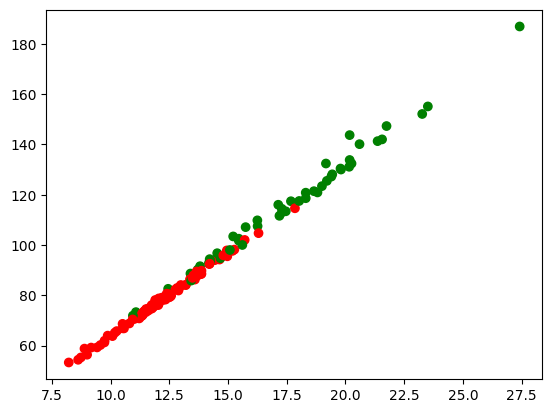

In [11]:
plt.scatter(df['Radius'],df['Perimeter'],c=df['Label'].map(color_dict))

<font color='green'> 
    
To complete
</font>

## b) Circle fitting using linear regression on cells' features

We will now assess more rigorously the circularity of the breast cells from the Wisconsin dataset, using linear regression. More precisely, we look for a relationship between the perimeter $p$ and the radius $r$ under the form: 

<center>$p = w_0 + w_1r$ </center>

Thus, $w_0$ and $w_1$ are the unknown variables we want to optimize.

<font color='blue'> Question 5: supposing breast cells are circular, what are the expected values for $w_1$ and  $w_0$? </font>

<font color='green'>  
w0 = 0 
w1 = 2pi
</font>

 We will now focus on linear regression. The loss to minimize is then written:
 
$ L(w_0, w_1) = \displaystyle \frac{1}{n} \sum_{i=1}^n (p_i - w_0 - w_1r_i) ^ 2$ 
 
 with $n$ the number of samples in the dataset, $p_i$ the perimeter of sample $i$ and $r_i$ the radius of this same sample. This loss, actually the Mean Squared Error (MSE) of the predicted perimeter with respect to the measured perimeter, is usually minimized direclty solving $\boldsymbol \nabla L(\boldsymbol w) = \boldsymbol 0$. For pedagogical purposes, we will compare the performances using gradient descent and conjugate gradient.

<font color='blue'> Question 6: complete the following functions to perform linear regression on the previous loss $L$ using gradient descent. </font>

In [14]:
def loss_function(w, y, x):

    """
    Loss function used in a linear regression between two input variables 
    y and x, so that y = w0 + w1 * x,
    with w0 and w1 the variables to optimize.
    
    Inputs
    ----------
    w: vector
        the variable vector w = [w0, w1]
    y: vector
        the vector containing the y variable values
    x: vector
        the vector containing the x variable values
        
    Outputs
    -------
    loss_val: float
        the loss value
        
    Command:
    loss_val = loss_function(w, y, x)
    
    """
    
    # Compute the loss value
    loss_val = np.mean((y - w[0] - w[1]*x)**2)
    
    return loss_val
print(loss_function([0,0],df['Perimeter'],df['Radius']))

8757.672133333332


In [15]:
def gradient_function(w, y, x):

    """
    Gradient of the loss function used in a linear regression between 
    two input variables y and x, so that y = w0 + w1 * x 
    with w0 and w1 the variables to optimize.
    
    Inputs
    ----------
    w: vector
        the variable vector w = [w0, w1]
    y: vector
        the vector containing the y variable values
    x: vector
        the vector containing the x variable values
        
    Outputs
    -------
    loss_grad: float
        the gradient vector 
        
    Command:
    loss_grad = gradient_function(w, y, x)
    
    """
    
    # Get the input variables
    w0, w1 = w

    n = len(y)
    prediction = w0 + w1 * x
    erreur = prediction - y
    
    # Compute the partial derivative of the loss with respect to w0
    d_w0 = (2/n) * np.sum(erreur)
    d_w1 = (2/n) * np.sum(erreur * x) 
    
    # Return the gradient vector 
    loss_grad = np.array([d_w0, d_w1])
    
    return loss_grad

In [19]:
# Regression using gradient descent
def my_regression(w, y, x, lr, nb_its):   
    
    """
    Linear regression between two known input vectors y and x,
    so that y = w0 + w1 * x, with w0 and w1 the variables to optimize.
    
    
    Parameters
    ----------
    w: vector of floats
        the input variable vector w = (w0, w1)
    y: vector of floats
        the vector containing the first variable values
    x: vector of floats
        the vector containing the second variable values
    lr : float
        the learning rate
    nb_its : strictly positive integer
        the number of iterations
        
    Returns
    -------
    w: vector of floats
        the input variable vector w = (w0, w1)
    losses: vector of floats
        the vector of loss values over the iterations
        
    Command:
    w, losses = my_regression(w, y, x, lr, nb_its)
    
    """
    
    #Initialize the loss vector
    losses = [loss_function(w, y, x)]
    
    # Perform Gradient Descent 
    for i in range(nb_its): 
        
        #Compute the gradient of the loss
        loss_grad = gradient_function(w,y,x)
        
        # Compute the updated w vector
        w = w - lr * loss_grad
        
        # Compute the updated loss value
        loss = loss_function(w, y, x)
        
        # Update the vector of losses
        losses.append(loss)
    
    return w, losses

<font color='blue'> Question 7: for each distinct label value, perform linear regression using gradient descent:
- Initialize the process using the expected value of $w_0$ and $w_1$, and display the initial loss value.
- Perform gradient descent using *my_regression* function, with a learning rate equal to 0.001 and 500 iterations.
- Display the optimal $w_0$ and $w_1$ and loss values.
- Superimpose the optimized line on the figure of the perimeter in function of the radius.
</font>


--- benign ---
Initial loss: 41.42983462677018
Optimal w0, w1: [-0.08966351  6.62168102]
Final loss: 6.285108432395974

--- malignant ---
Initial loss: 3.4271435132900985
Optimal w0, w1: [-0.0242175   6.42188378]
Final loss: 0.6018382882077323


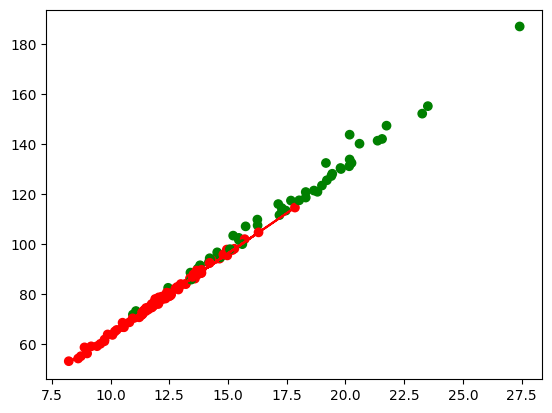

In [20]:
plt.scatter(df['Radius'], df['Perimeter'], c=df['Label'].map(color_dict))

for label in ['benign', 'malignant']:
    print(f"\n--- {label} ---")
    # Extraction des données
    x = df[df['Label'] == label]['Radius'].values
    y = df[df['Label'] == label]['Perimeter'].values
    # Initialisation (w0 = 0, w1 = 2*pi) et affichage
    w = np.array([0.0, 2 * np.pi])
    print("Initial loss:", loss_function(w, y, x))
    # Descente de gradient
    w_opt, losses = my_regression(w, y, x, 0.001, 500)
    # Affichage des résultats optimaux
    print("Optimal w0, w1:", w_opt)
    print("Final loss:", losses[-1])
    # Tracé de la droite de régression
plt.plot(x, w_opt[0] + w_opt[1] * x, color=color_dict[label])

<font color='blue'> Question 8: visually and quantitatively assess the performances of the algorithm for each label. More precisely, answer these questions:
- Did the optimization algorithm work?
- Is there a difference in circularity between malignant and benign cells?
</font>

<font color='green'> 
    
To complete
</font>

We will now assess the convergence of the algorithm displaying the evolution of the loss iver iterations.

<font color='blue'> Question 9: display the evolution of the loss for each label. Did the algorithm converge?
</font>

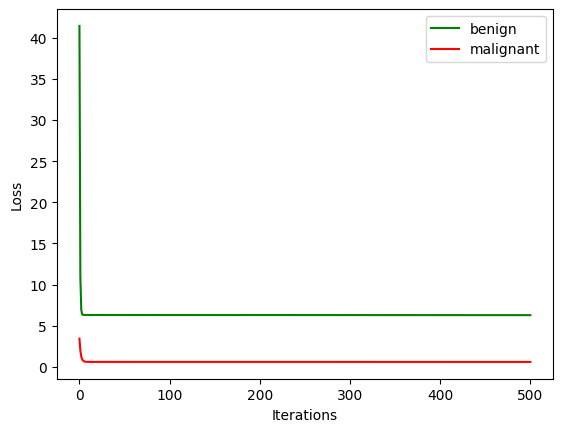

In [21]:
for label in ['benign', 'malignant']:
    x = df[df['Label'] == label]['Radius'].values
    y = df[df['Label'] == label]['Perimeter'].values
    # On relance la régression pour récupérer l'historique des 'losses'
    _, losses = my_regression(np.array([0.0, 2 * np.pi]), y, x, 0.001, 500)
    # Tracé de la courbe
    plt.plot(losses, label=label, color=color_dict[label])

plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

<font color='green'> 
To complete
</font>

We will now compare the performances between gradient descent or conjugate gradients.

# II. Linear regression on breast cells' features using Conjugate Gradient

<font color='blue'> <font color='blue'> Question 10: use the *minimize* function of Scipy with the appropriate parameters to apply Conjugate Gradient on our problem - making the difference between each label. How many iterations are needed for convergence? Display also the evolution of the loss over the iterations. Compare the performances between gradient descent and conjugate gradient and conclude.
</font>

C:\Users\yannr\AppData\Local\Temp\ipykernel_13556\572772694.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


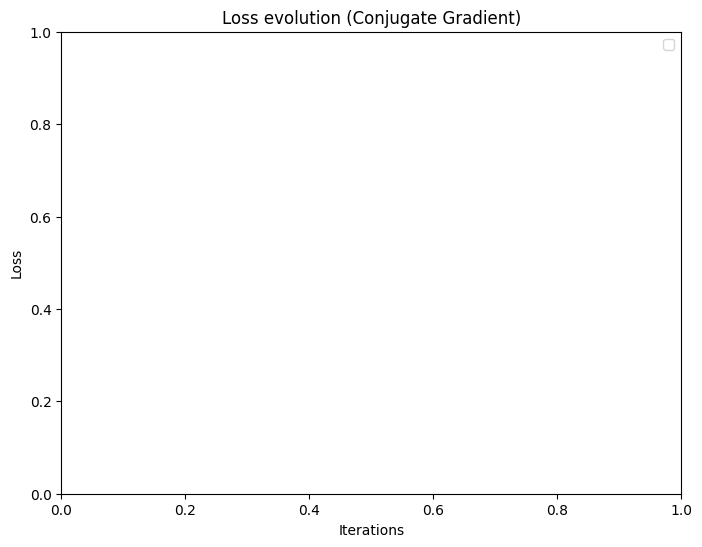

In [23]:


plt.figure(figsize=(8, 6))

for label in ['benign', 'malignant']:
    # 1. Extraction des données
    x = df[df['Label'] == label]['Radius'].values
    y = df[df['Label'] == label]['Perimeter'].values
    # Initialisation
    w_init = np.array([0.0, 2 * np.pi])
    # Liste pour stocker l'évolution de la loss (on y met la loss initiale)
    loss_history = [loss_function(w_init, y, x)]
    # Fonction appelée à chaque itération par scipy pour stocker la loss
    
def callback_tracker(w):
    loss_history.append(loss_function(w, y, x))
    # 2. Lancement du Gradient Conjugué
    res = minimize(loss_function, w_init, args=(y, x), method='CG', jac=gradient_function, callback=callback_tracker)
    # 3. Affichage du nombre d'itérations
    print(f"--- {label} ---")
    print(f"Iterations needed for convergence: {res.nit}")
    # Tracé
    plt.plot(loss_history, label=f"{label} (CG)", color=color_dict[label], marker='o')

plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Loss evolution (Conjugate Gradient)')
plt.legend()
plt.show()


<font color='green'> 
To complete
</font>